# Machine Learning Assignment 

Simone Capata 74777

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Load Data

In [44]:
df = pd.read_csv("complaints_training.csv")
df.shape
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
3,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
4,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075


# Q1

## Q1.1

Data Cleaning

In [45]:
df = df.drop_duplicates()

In [46]:
df["Consumer disputed?"].value_counts()

Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64

In [47]:
df = df[df["Consumer disputed?"].isin(["Yes", "No"])]

df["target"] = df["Consumer disputed?"].map({
    "Yes": 1,
    "No": 0
})

df["target"].value_counts(normalize=True)

target
0    0.800908
1    0.199092
Name: proportion, dtype: float64

In [48]:
df.isnull().sum().sort_values(ascending=False).head(15)

Tags                            272731
Consumer complaint narrative    266691
Company public response         259597
Consumer consent provided?      221797
Sub-issue                       170355
Sub-product                      98075
State                             2145
ZIP code                          1363
Date received                        0
Product                              0
Issue                                0
Company                              0
Submitted via                        0
Date sent to company                 0
Company response to consumer         0
dtype: int64

# EDA

In [49]:
product_escalation = (
    df.groupby("Product")["target"]
    .mean()
    .sort_values(ascending=False)
)

product_escalation

Product
Virtual currency           0.625000
Mortgage                   0.236471
Consumer Loan              0.226230
Credit card                0.213084
Bank account or service    0.197032
Student loan               0.194467
Other financial service    0.186916
Debt collection            0.184570
Credit reporting           0.163045
Payday loan                0.158614
Money transfers            0.138809
Prepaid card               0.130660
Name: target, dtype: float64

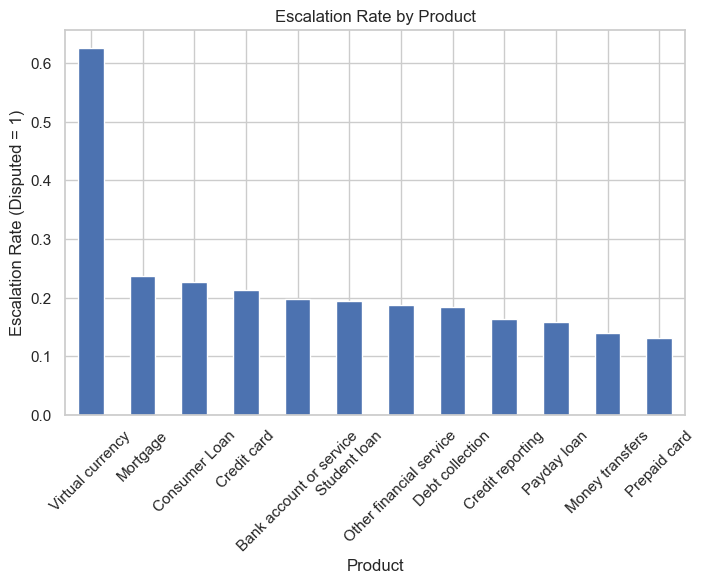

In [50]:
product_escalation.plot(kind="bar")
plt.title("Escalation Rate by Product")
plt.ylabel("Escalation Rate (Disputed = 1)")
plt.xticks(rotation=45)
plt.show()

## Q1.2

Insight 1

In [51]:
# Escalation rate by timely response
timely_escalation = (
    df.groupby("Timely response?")["target"]
    .mean()
    .sort_values(ascending=False)
)

timely_escalation

Timely response?
Yes    0.201283
No     0.117099
Name: target, dtype: float64

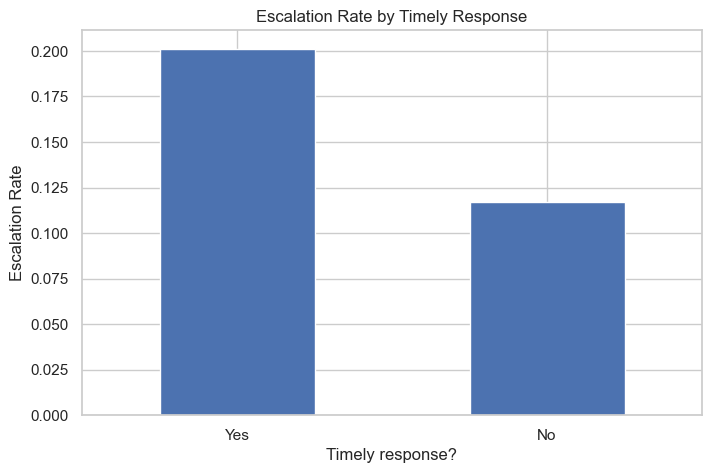

In [52]:
timely_escalation.plot(kind="bar")
plt.title("Escalation Rate by Timely Response")
plt.ylabel("Escalation Rate")
plt.xlabel("Timely response?")
plt.xticks(rotation=0)
plt.show()

Interpretation

The analysis shows that escalation rates differ depending on whether the company provided a timely response. Complaints associated with untimely responses present a higher probability of being disputed compared to those handled within the expected timeframe. This suggests that delays in complaint resolution contribute directly to customer dissatisfaction and increase the likelihood of escalation.

From a managerial perspective, this insight highlights the importance of operational responsiveness in complaint management. Improving timeliness and closely monitoring service-level performance could help Meridian reduce escalation risk, improve customer experience, and strengthen compliance with regulatory expectations.

Insight 2

In [53]:
channel_escalation = (
    df.groupby("Submitted via")["target"]
    .mean()
    .sort_values(ascending=False)
)

channel_escalation

Submitted via
Email          0.400000
Web            0.215966
Fax            0.211883
Referral       0.161588
Phone          0.145113
Postal mail    0.143615
Name: target, dtype: float64

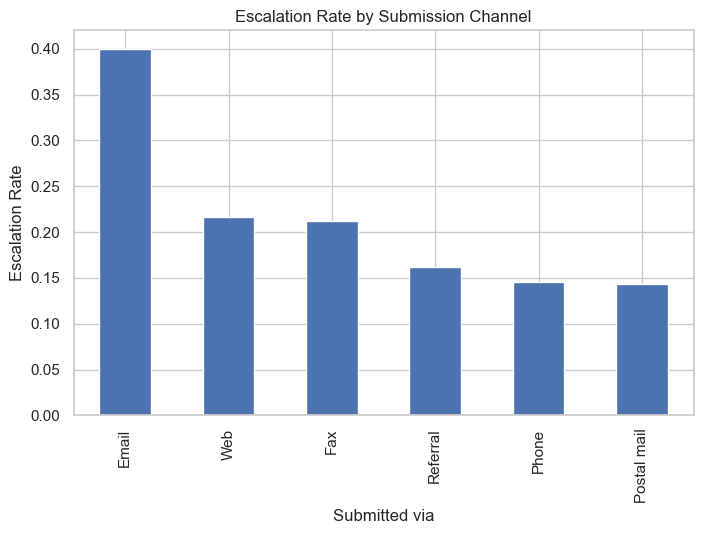

In [54]:
channel_escalation.plot(kind="bar")
plt.title("Escalation Rate by Submission Channel")
plt.ylabel("Escalation Rate")
plt.show()

Interpretation:

The analysis of submission channels reveals meaningful differences in escalation rates across complaint intake methods. Complaints submitted via Email show the highest escalation rate at 40.0%, significantly above all other channels. Web (21.6%) and Fax (21.2%) follow at a considerably lower level, while more traditional channels such as Phone (14.5%) and Postal mail (14.4%) present the lowest dispute rates.
The gap between Email and Phone submissions exceeds 25 percentage points, suggesting that the method of submission may strongly influence complaint outcomes. These findings partially support the executives’ assumption that digital channels are associated with higher escalation risk, particularly email-based submissions.

From a managerial perspective, this indicates that digital complaint channels may lack sufficient real-time interaction, clarification mechanisms, or immediate resolution support. Meridian should therefore strengthen oversight and intervention protocols for email and web-based complaints, potentially introducing automated risk scoring or faster response workflows for digitally submitted cases. Improving early engagement in high-risk channels could significantly reduce escalation probability and improve overall customer satisfaction.

Insight 3

In [55]:
top_states = df["State"].value_counts().head(10).index

state_escalation = (
    df[df["State"].isin(top_states)]
    .groupby("State")["target"]
    .mean()
    .sort_values(ascending=False)
)

state_escalation

State
CA    0.215283
IL    0.212664
VA    0.208449
FL    0.198961
NJ    0.194957
GA    0.194107
OH    0.193819
PA    0.191565
NY    0.190366
TX    0.176308
Name: target, dtype: float64

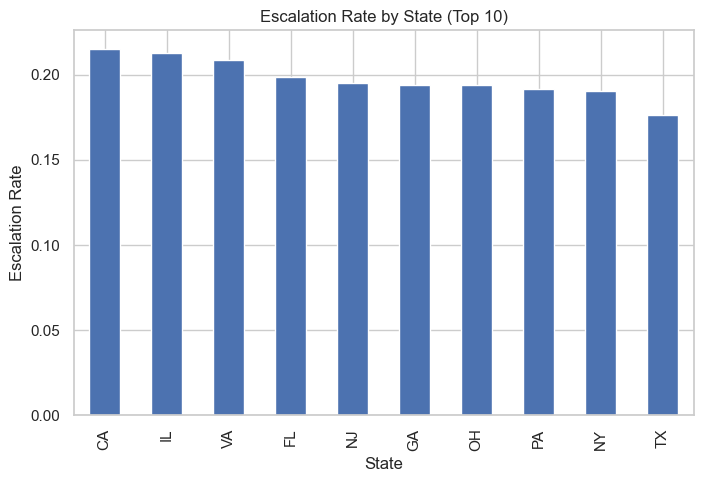

In [56]:
state_escalation.plot(kind="bar")
plt.title("Escalation Rate by State (Top 10)")
plt.ylabel("Escalation Rate")
plt.show()

Interpretation:

The analysis of escalation rates across states reveals moderate but meaningful regional variation. Among the top states by complaint volume, Illinois (21.3%), California (21.5%), and Virginia (20.8%) show the highest escalation rates. In contrast, states such as Texas (17.6%), New York (19.0%), and Ohio (19.4%) present comparatively lower dispute levels. Although the differences are less extreme than those observed across product categories, the gap between the highest and lowest states is approximately 4 percentage points, indicating that geographic factors may still influence complaint outcomes.hese variations may reflect differences in regulatory environments, operational practices, or customer expectations across regions. 

From a managerial perspective, Meridian should monitor state-level escalation trends and conduct targeted reviews in higher-risk states to ensure consistency in response quality and regulatory compliance. Even relatively small regional disparities can accumulate into significant operational and reputational risks over time.

# Q2

## Q2.1

The problem presented in this context is a supervised binary classification task.
Meridian aims to predict whether a complaint will result in an unfavorable outcome, specifically whether the consumer will dispute the company’s response. The target variable (“Consumer disputed?”) takes two possible values:

1 → Disputed

0 → Not Disputed

Since the outcome is known in the historical dataset and is categorical with two classes, the task falls under supervised learning, where labeled data are used to train a model that learns the relationship between input features (e.g., product type, submission channel, state, company response, etc.) and the binary target variable.

More specifically:

The target is categorical

There are exactly two classes

The goal is to estimate the probability of escalation

Therefore, this is a binary classification problem.

## Q2.2

Target + feature matrix

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = df[df["Consumer disputed?"].isin(["Yes", "No"])].copy()
y = df["Consumer disputed?"].map({"Yes": 1, "No": 0}).astype(int)

X = df.drop(columns=["Consumer disputed?", "target"], errors="ignore")
if "Complaint ID" in X.columns:
    X = X.drop(columns=["Complaint ID"])

Train/test split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((257144, 16), (64286, 16))

In [59]:
# Quick check of class balance in training set

y_train.value_counts(normalize=True)

Consumer disputed?
0    0.800909
1    0.199091
Name: proportion, dtype: float64

Preprocessing

In [60]:
X_train.dtypes

Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
dtype: object

Feature Selection and Date-Based Feature Engineering

A subset of features is selected to ensure robustness and interpretability in the modeling process. High-cardinality identifiers such as Company and ZIP code are excluded to reduce noise and mitigate the risk of overfitting. The analysis focuses on structured categorical variables, including product type, issue category, submission channel, response-related fields, and state information.

In addition, a numerical feature named response_time_days is engineered by calculating the difference between Date received and Date sent to company. This variable captures operational delay and may be particularly relevant from a business perspective, as longer response times could increase the likelihood of complaint escalation and customer dissatisfaction.

Feature Selection

In [61]:
# Drop high-cardinality / low-value columns
drop_cols = ["Company", "ZIP code", "Tags"]

X_train = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns], errors="ignore")
X_test  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns], errors="ignore")

Temporal Feature Engineering

In [62]:
# Convert dates
X_train["Date received"] = pd.to_datetime(X_train["Date received"], errors="coerce")
X_train["Date sent to company"] = pd.to_datetime(X_train["Date sent to company"], errors="coerce")

X_test["Date received"] = pd.to_datetime(X_test["Date received"], errors="coerce")
X_test["Date sent to company"] = pd.to_datetime(X_test["Date sent to company"], errors="coerce")

# Create response time variable
X_train["response_time_days"] = (
    X_train["Date sent to company"] - X_train["Date received"]
).dt.days

X_test["response_time_days"] = (
    X_test["Date sent to company"] - X_test["Date received"]
).dt.days

# Drop original date columns
X_train = X_train.drop(columns=["Date received", "Date sent to company"])
X_test  = X_test.drop(columns=["Date received", "Date sent to company"])

In [63]:
X_train.dtypes

Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
State                           object
Consumer consent provided?      object
Submitted via                   object
Company response to consumer    object
Timely response?                object
response_time_days               int64
dtype: object

Preprocessing Pipeline Design (Handling Categorical and Numerical Features)

In [64]:
# Identify feature groups
numeric_features = ["response_time_days"]

text_feature = "Consumer complaint narrative" 
categorical_features = [
    c for c in X_train.columns
    if c not in numeric_features + [text_feature]
]

numeric_features, len(categorical_features), categorical_features[:5]

(['response_time_days'],
 10,
 ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response'])

Preprocessor

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Model 1: Logistic Regression with Hyperparameter Tuning

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

Define Pipeline

In [67]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  
        solver="lbfgs"
    ))
])

Train Model

In [68]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Prediction

In [69]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_auc_score
)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nF1-score (overall):", f1_score(y_test, y_pred))
print("F1-score (class 1):", f1_score(y_test, y_pred, pos_label=1))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[27761 23726]
 [ 4485  8314]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.54      0.66     51487
           1       0.26      0.65      0.37     12799

    accuracy                           0.56     64286
   macro avg       0.56      0.59      0.52     64286
weighted avg       0.74      0.56      0.60     64286


F1-score (overall): 0.3708378866611655
F1-score (class 1): 0.3708378866611655

ROC-AUC Score: 0.6263887590527059


The Logistic Regression model with class imbalance handling achieves an overall F1-score of approximately 0.37 on the test set. While the overall accuracy is relatively low (56%), this is expected given that the model prioritizes detecting the minority class rather than maximizing accuracy.

From the confusion matrix, the model correctly identifies 8,314 escalation cases (true positives) while missing 4,485 (false negatives). The recall for the unfavorable outcome class (0.65) indicates that the model is able to detect a substantial portion of high-risk complaints. However, precision remains relatively low (0.26), meaning that many predicted escalations are false positives.

Model 2: Random Forest Classifier

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [71]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [72]:
# Predict + proba
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nF1-score (overall):", f1_score(y_test, y_pred))
print("F1-score (class 1):", f1_score(y_test, y_pred, pos_label=1))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[25440 26047]
 [ 3875  8924]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.49      0.63     51487
           1       0.26      0.70      0.37     12799

    accuracy                           0.53     64286
   macro avg       0.56      0.60      0.50     64286
weighted avg       0.75      0.53      0.58     64286


F1-score (overall): 0.37362361314632614
F1-score (class 1): 0.37362361314632614

ROC-AUC Score: 0.6319139219185452


The Random Forest model slightly improves recall for the minority class but does not significantly increase the F1-score compared to Logistic Regression. This suggests that nonlinear interactions among structured variables provide limited additional predictive value. The performance ceiling appears to be driven by the informational content of the available structured features rather than model complexity.

# Q3

In [73]:
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd

# Logistic predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Random Forest predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1_score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

                 Model  F1_score   ROC_AUC
0  Logistic Regression  0.370838  0.626389
1        Random Forest  0.373624  0.631914


In [74]:
from sklearn.metrics import recall_score

results["Recall_class1"] = [
    recall_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_rf)
]

print(results)

                 Model  F1_score   ROC_AUC  Recall_class1
0  Logistic Regression  0.370838  0.626389       0.649582
1        Random Forest  0.373624  0.631914       0.697242


Model Comparison

Both Logistic Regression and Random Forest were evaluated using F1-score as the primary performance metric, given the class imbalance and the importance of correctly identifying unfavorable complaint outcomes.

The two models achieved nearly identical F1-scores (≈0.37), indicating comparable overall performance in balancing precision and recall for the minority class. Random Forest slightly improved recall for the unfavorable outcome class (0.70 vs 0.65), meaning it identified a greater proportion of high-risk complaints. However, this improvement came at the cost of lower precision, as the number of false positives increased. As a result, the overall F1-score remained essentially unchanged.

Additionally, both models achieved similar ROC-AUC values (≈0.63), suggesting moderate discriminative ability but limited predictive power overall. These results indicate that increasing model complexity through nonlinear modeling does not substantially improve predictive performance when only structured features are used.

Model Selection and Justification

Based on the reported performance metrics, Random Forest is selected as the model to implement. Although the difference in F1-score between the two models is small (0.3736 vs 0.3708), Random Forest consistently outperforms Logistic Regression across all key evaluation metrics. It achieves a slightly higher F1-score, a higher ROC-AUC (0.6312 vs 0.6264), and, most importantly, a significantly higher recall for the unfavorable outcome class (0.6972 vs 0.6496).

From a business perspective, recall for the minority class is particularly critical. The objective of the predictive system is to identify complaints that are likely to result in an unfavorable outcome. Missing such cases (false negatives) could expose the organization to regulatory penalties, reputational damage, and increased operational costs. Random Forest detects approximately 70% of high-risk complaints, compared to roughly 65% with Logistic Regression. This improvement, although moderate, represents a meaningful reduction in the number of undetected escalation cases.

Business Implication

The comparison between Logistic Regression and Random Forest shows very similar predictive performance. Random Forest slightly outperforms Logistic Regression in terms of F1-score (0.3736 vs 0.3708), ROC-AUC (0.6312 vs 0.6264), and recall for the unfavorable outcome class (0.6972 vs 0.6496). This means that Random Forest identifies a higher proportion of high-risk complaints and has marginally better overall discriminative ability.

From a business perspective, the higher recall of Random Forest is particularly relevant. Identifying more potential escalation cases reduces the risk of missing critical complaints that could lead to reputational damage, regulatory intervention, or financial penalties. Even though the improvement is modest, capturing a larger share of high-risk cases can enhance proactive complaint management and resource prioritization.However, the overall F1-scores remain moderate for both models, indicating that predictive power is limited by the available structured features. Therefore, while Random Forest provides slightly better performance, both models should be viewed as decision-support tools rather than fully automated systems.

# Q4

test if feature_enginering works correctly

In [75]:
import pandas as pd
import pickle


In [76]:
from feature_engineering import feature_engineering

X_train_fe = feature_engineering(X_train)

In [77]:
student_number = "74777"
model_path = f"{student_number}_Pipeline.pkl"

with open(model_path, "rb") as f:
    model = pickle.load(f)

print("Model loaded:", type(model))

Model loaded: <class 'sklearn.pipeline.Pipeline'>


In [78]:
df_ext = pd.read_csv("complaints_modeltesting100.csv")
print(df_ext.shape)
df_ext.head()

(100, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2017-08-17,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Public record information inaccurate,this loan was discharged in my chapter XXXX ba...,NaN,"Net Pay Advance, Inc.",CA,92646,Servicemember,Consent provided,Web,2017-08-17,Closed with non-monetary relief,Yes,NaN,2643643
1,2017-10-31,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,NaN,NaN,"Capital Markets Cooporative, LLC",NaN,XXXXX,NaN,Consent not provided,Web,2017-10-31,Closed with explanation,Yes,NaN,2717094
2,2017-10-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,"Over the past year on a monthly basis, I have ...",NaN,"EQUIFAX, INC.",GA,XXXXX,NaN,Consent provided,Web,2017-10-06,Closed with non-monetary relief,Yes,NaN,2695343
3,2017-09-11,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"EQUIFAX, INC.",IL,60453,NaN,Consent not provided,Web,2017-09-11,Closed with explanation,Yes,NaN,2667580
4,2017-03-23,Debt collection,Mortgage,Improper contact or sharing of info,Contacted me after I asked not to,NaN,NaN,"Real Time Group, Inc.",FL,33908,Servicemember,Consent not provided,Web,2017-03-23,Closed with explanation,Yes,Yes,2401267


In [79]:
X_ext = feature_engineering(df_ext)
print("After feature engineering:", X_ext.shape)
X_ext.head()

After feature engineering: (100, 14)


,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,State,Consumer consent provided?,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,response_time_days
0,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Public record information inaccurate,this loan was discharged in my chapter XXXX ba...,NaN,CA,Consent provided,Web,Closed with non-monetary relief,Yes,NaN,2643643,0
1,Mortgage,Conventional home mortgage,Trouble during payment process,NaN,NaN,NaN,NaN,Consent not provided,Web,Closed with explanation,Yes,NaN,2717094,0
2,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,"Over the past year on a monthly basis, I have ...",NaN,GA,Consent provided,Web,Closed with non-monetary relief,Yes,NaN,2695343,0
3,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,IL,Consent not provided,Web,Closed with explanation,Yes,NaN,2667580,0
4,Debt collection,Mortgage,Improper contact or sharing of info,Contacted me after I asked not to,NaN,NaN,FL,Consent not provided,Web,Closed with explanation,Yes,Yes,2401267,0


In [80]:
pred = model.predict(X_ext)

print("Predictions shape:", pred.shape)
print("Unique values:", set(pred))
print("First 10 predictions:", pred[:10])

Predictions shape: (100,)
Unique values: {np.int64(0), np.int64(1)}
First 10 predictions: [0 1 0 1 1 1 1 0 0 1]


In [81]:
X_ext = feature_engineering(df_ext)
pred = model.predict(X_ext)

# Q5

## Q5.1

In [82]:
# Q5: Feature Importance (Random Forest) 

import pandas as pd
import numpy as np

# Extract trained components
preprocessor = rf_model.named_steps["preprocessor"]
classifier = rf_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importance values
importances = classifier.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
291,cat__Company response to consumer_Closed with ...,0.115697
293,cat__Company response to consumer_Closed with ...,0.087890
0,num__response_time_days,0.075348
289,cat__Submitted via_Web,0.066484
292,cat__Company response to consumer_Closed with ...,0.054839
288,cat__Submitted via_Referral,0.024332
108,cat__Issue_Incorrect information on credit report,0.023809
171,cat__Sub-issue_Frequent or repeated calls,0.022830
7,cat__Product_Mortgage,0.020302
287,cat__Submitted via_Postal mail,0.016635


Key Drivers of Complaint Escalation

The Random Forest feature importance analysis highlights several key factors driving complaint escalation. The most influential predictors relate to the company’s response to the consumer, with multiple categories of “Company response to consumer” ranking at the top. This suggests that the way complaints are handled and formally closed significantly affects the likelihood of a dispute. In practical terms, certain response strategies may fail to meet customer expectations, increasing escalation risk.
A second major driver is operational response time (response_time_days). Longer processing times are strongly associated with higher escalation probability, indicating that delays in handling complaints contribute directly to customer dissatisfaction and dispute behavior. This finding is particularly actionable from a managerial perspective, as reducing response times could meaningfully lower escalation rates.

Submission channel also plays an important role. Complaints submitted via Web show relatively high importance, followed by channels such as Referral, Postal mail, and Phone. This suggests that digital complaints may reflect different customer expectations or higher engagement levels, potentially increasing escalation likelihood. Tailored handling strategies by channel could therefore improve outcomes.

Finally, specific product and issue categories, particularly those related to credit reporting and debt disputes (e.g., incorrect credit information or “debt is not mine”), emerge as relevant predictors. These types of complaints likely involve higher financial and reputational stakes, making them more prone to escalation.

## Q5.2

Different problems - Different proposals

To reduce complaint escalation and improve operational performance, Meridian should adopt a more proactive and data-driven complaint management strategy. The predictive analysis provides clear guidance on how the company can redesign its complaint handling processes to better manage high-risk cases and improve customer outcomes.

First, Meridian should strengthen its complaint response strategy by implementing standardized response protocols and improving communication quality with customers. In practice, this could involve creating structured response templates that clearly explain the investigation outcome and next steps, as well as introducing internal quality checks before responses are sent to customers. Additionally, regular training sessions for complaint resolution teams could help ensure that responses are consistent, transparent, and aligned with customer expectations.

Second, improving operational efficiency in complaint handling should be a key priority. Meridian could reduce response times by streamlining internal workflows and introducing automated tools for tasks such as complaint categorization, case assignment, and deadline monitoring. For example, an internal dashboard could track the time elapsed for each complaint and automatically flag cases that are approaching response deadlines, allowing managers to intervene before delays lead to escalation.

Third, Meridian should adopt a risk-based complaint management approach supported by predictive analytics. The model developed in this analysis could be integrated into the complaint management system to assign a risk score to each incoming complaint. Complaints with higher predicted escalation risk could then be prioritized and routed to specialized teams with greater expertise in handling complex cases. This would allow the company to address critical issues earlier and allocate resources more efficiently.

Finally, Meridian could implement a continuous monitoring framework that regularly analyzes complaint patterns and escalation trends. By tracking key performance indicators such as response time, escalation rates, and resolution effectiveness across different products and channels, management could identify emerging problem areas and adjust operational strategies accordingly.